# CHRONIC KIDNEY DISEASE RISK PREDICTION: A DATA-DRIVEN APPROACH

## Introduction

Chronic Kidney Disease (CKD) is a growing health concern, affecting millions of people worldwide. CKD is a gradual loss of kidney function over time, leading to serrious complications, such as kidney failure, cardiovascular disease, and even death. Early detection and diagnosis of CKD are crucial for preventing or delaying diesease progression.

This project aims to develop a predictive model using machine learning techniques to identify patients at risk of being diagnosed with CKD. By leveraging a health-related dataset, this study seeks to contribute to the development of a more accurate and efficient CKD risk assesment tool.

## Objectives

* Develop a predictive model.
* Identify key risk factors.
* Compare and evaluate model performance.

## Data Importation, Cleaning and Manipulation

The first step would be importing the neccessary libraries and the data required for this project.

In [102]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
# Now let's import and load the data

df = pd.read_csv('kidney_disease.csv')

df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


### Column Glossary

Below is a detailed description of the columns (features) found in this dataset:

* id: Unique identifier for each row in the dataset

Patient Demographics:
* age: Age of the patient (in years).
* bp: Blood pressure (in mm/Hg).

Clinical Features:
* sg: Specific gravity (a measure of urine concentration, e.g., 1.005 to 1.025).
* al: Albumin levels in urine (graded from 0 to 5, higher levels indicate kidney damage).
* su: Sugar levels in urine (graded from 0 to 5).
* rbc: Red blood cells in urine (normal or abnormal).
* pc: Pus cells in urine (normal or abnormal).
* pcc: Pus cell clumps in urine (present or not present).
* ba: Bacteria in urine (present or not present).

Blood Test Results:
* bgr: Blood glucose random (mg/dL).
* bu: Blood urea (mg/dL).
* sc: Serum creatinine (mg/dL).
* sod: Sodium levels in blood (mEq/L).
* pot: Potassium levels in blood (mEq/L).
* hemo: Hemoglobin level (g/dL).
* pcv: Packed cell volume (percentage or numeric value).
* wbcc: White blood cell count (per cubic mm).
* rbcc: Red blood cell count (millions/cubic mm).
                              
Other Indicators:
* htn: Hypertension (yes or no).
* dm: Diabetes mellitus (yes or no).
* cad: Coronary artery disease (yes or no).
* appet: Appetite (good or poor).
* pe: Presence of pedal edema (yes or no).
* ane: Presence of anemia (yes or no).

Target Variable:
* classification: Whether the patient has chronic kidney disease (ckd) or not (notckd).

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [105]:
# As further cleaning needs to be carried out, such as filling the empty values, certain columns' datatypes neede to be changed.

df['pcv'] = pd.to_numeric(df['pcv'], errors = 'coerce')
df['wc'] = pd.to_numeric(df['wc'], errors = 'coerce')
df['rc'] = pd.to_numeric(df['rc'], errors = 'coerce')

In [106]:
# Now, to see if those changes have been applied!

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             329 non-null    float64
 17  wc              294 non-null    flo

In [107]:
# Now that each columns have the right datatypes, I'll go ahead to check for duplicate values

df.duplicated().sum()

0

In [108]:
# With the absence of dupliate values, I'll check if the data has null/empty values.
# I'll be summing up all the null values in a column and if a column has a value > 0, it means that the column has null values in it.

df.isnull().sum()

id                  0
age                 9
bp                 12
sg                 47
al                 46
su                 49
rbc               152
pc                 65
pcc                 4
ba                  4
bgr                44
bu                 19
sc                 17
sod                87
pot                88
hemo               52
pcv                71
wc                106
rc                131
htn                 2
dm                  2
cad                 2
appet               1
pe                  1
ane                 1
classification      0
dtype: int64

* A lot of the columns in the data have null/empty entries and to ensure the data is appropriate and fit for analysis and also help me make better predictions, I'll be filling each numeric column (using a for loop) with their mean value, and each categorical column (using a lambda function) with their most occuring value.

In [109]:
num_col = df.select_dtypes(include = {'int', 'float'})

In [110]:
num_col.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot',
       'hemo', 'pcv', 'wc', 'rc'],
      dtype='object')

In [111]:
# For Loops:

for i in num_col.columns:
    df[i] = df[i].fillna(df[i].mean())

In [112]:
# Lambda Function

fill = lambda x: x.fillna(x.value_counts().index[0])

In [113]:
df = df.apply(fill)

In [114]:
df.isnull().sum()

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [115]:
# Now that the data has no empty entries, I'll change the age column from a float dtype to an integer

df['age'] = df['age'].astype(int)

In [116]:
# To ensure that all entries in the data are in the right format, I'll be using a for loop, iterating over each entry and making sure they all are in the right format

categorical_features = df.select_dtypes(include = 'object')

for col in categorical_features:
    print(df[col].value_counts())
    print('*********************************')

rbc
normal      353
abnormal     47
Name: count, dtype: int64
*********************************
pc
normal      324
abnormal     76
Name: count, dtype: int64
*********************************
pcc
notpresent    358
present        42
Name: count, dtype: int64
*********************************
ba
notpresent    378
present        22
Name: count, dtype: int64
*********************************
htn
no     253
yes    147
Name: count, dtype: int64
*********************************
dm
no       260
yes      134
\tno       3
\tyes      2
 yes       1
Name: count, dtype: int64
*********************************
cad
no      364
yes      34
\tno      2
Name: count, dtype: int64
*********************************
appet
good    318
poor     82
Name: count, dtype: int64
*********************************
pe
no     324
yes     76
Name: count, dtype: int64
*********************************
ane
no     340
yes     60
Name: count, dtype: int64
*********************************
classification
ckd       248
notckd

In [117]:
df['pcc'] = df['pcc'].replace({'notpresent':'not present'})
df['ba'] = df['ba'].replace({'notpresent':'not present'})
df['dm'] = df['dm'].replace({'\tno':'no', '\tyes':'yes', ' yes':'yes'})
df['cad'] = df['cad'].replace({'\tno':'no'})
df['classification'] = df['classification'].replace({'ckd\t':'ckd'})

for col in categorical_features:
    print(df[col].value_counts())
    print('***************************')

rbc
normal      353
abnormal     47
Name: count, dtype: int64
***************************
pc
normal      324
abnormal     76
Name: count, dtype: int64
***************************
pcc
not present    358
present         42
Name: count, dtype: int64
***************************
ba
not present    378
present         22
Name: count, dtype: int64
***************************
htn
no     253
yes    147
Name: count, dtype: int64
***************************
dm
no     263
yes    137
Name: count, dtype: int64
***************************
cad
no     366
yes     34
Name: count, dtype: int64
***************************
appet
good    318
poor     82
Name: count, dtype: int64
***************************
pe
no     324
yes     76
Name: count, dtype: int64
***************************
ane
no     340
yes     60
Name: count, dtype: int64
***************************
classification
ckd       250
notckd    150
Name: count, dtype: int64
***************************


## Preditive Modeling

In [118]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score

import warnings
warnings.filterwarnings('ignore')

In [119]:
le = LabelEncoder()

In [120]:
for col in categorical_features:
    df[col] = le.fit_transform(df[col])

df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48,80.0,1.020,1.0,0.0,1,1,0,0,...,44.0,7800.0,5.200000,1,1,0,0,0,0,0
1,1,7,50.0,1.020,4.0,0.0,1,1,0,0,...,38.0,6000.0,4.707435,0,0,0,0,0,0,0
2,2,62,80.0,1.010,2.0,3.0,1,1,0,0,...,31.0,7500.0,4.707435,0,1,0,1,0,1,0
3,3,48,70.0,1.005,4.0,0.0,1,0,1,0,...,32.0,6700.0,3.900000,1,0,0,1,1,1,0
4,4,51,80.0,1.010,2.0,0.0,1,1,0,0,...,35.0,7300.0,4.600000,0,0,0,0,0,0,0


<Axes: >

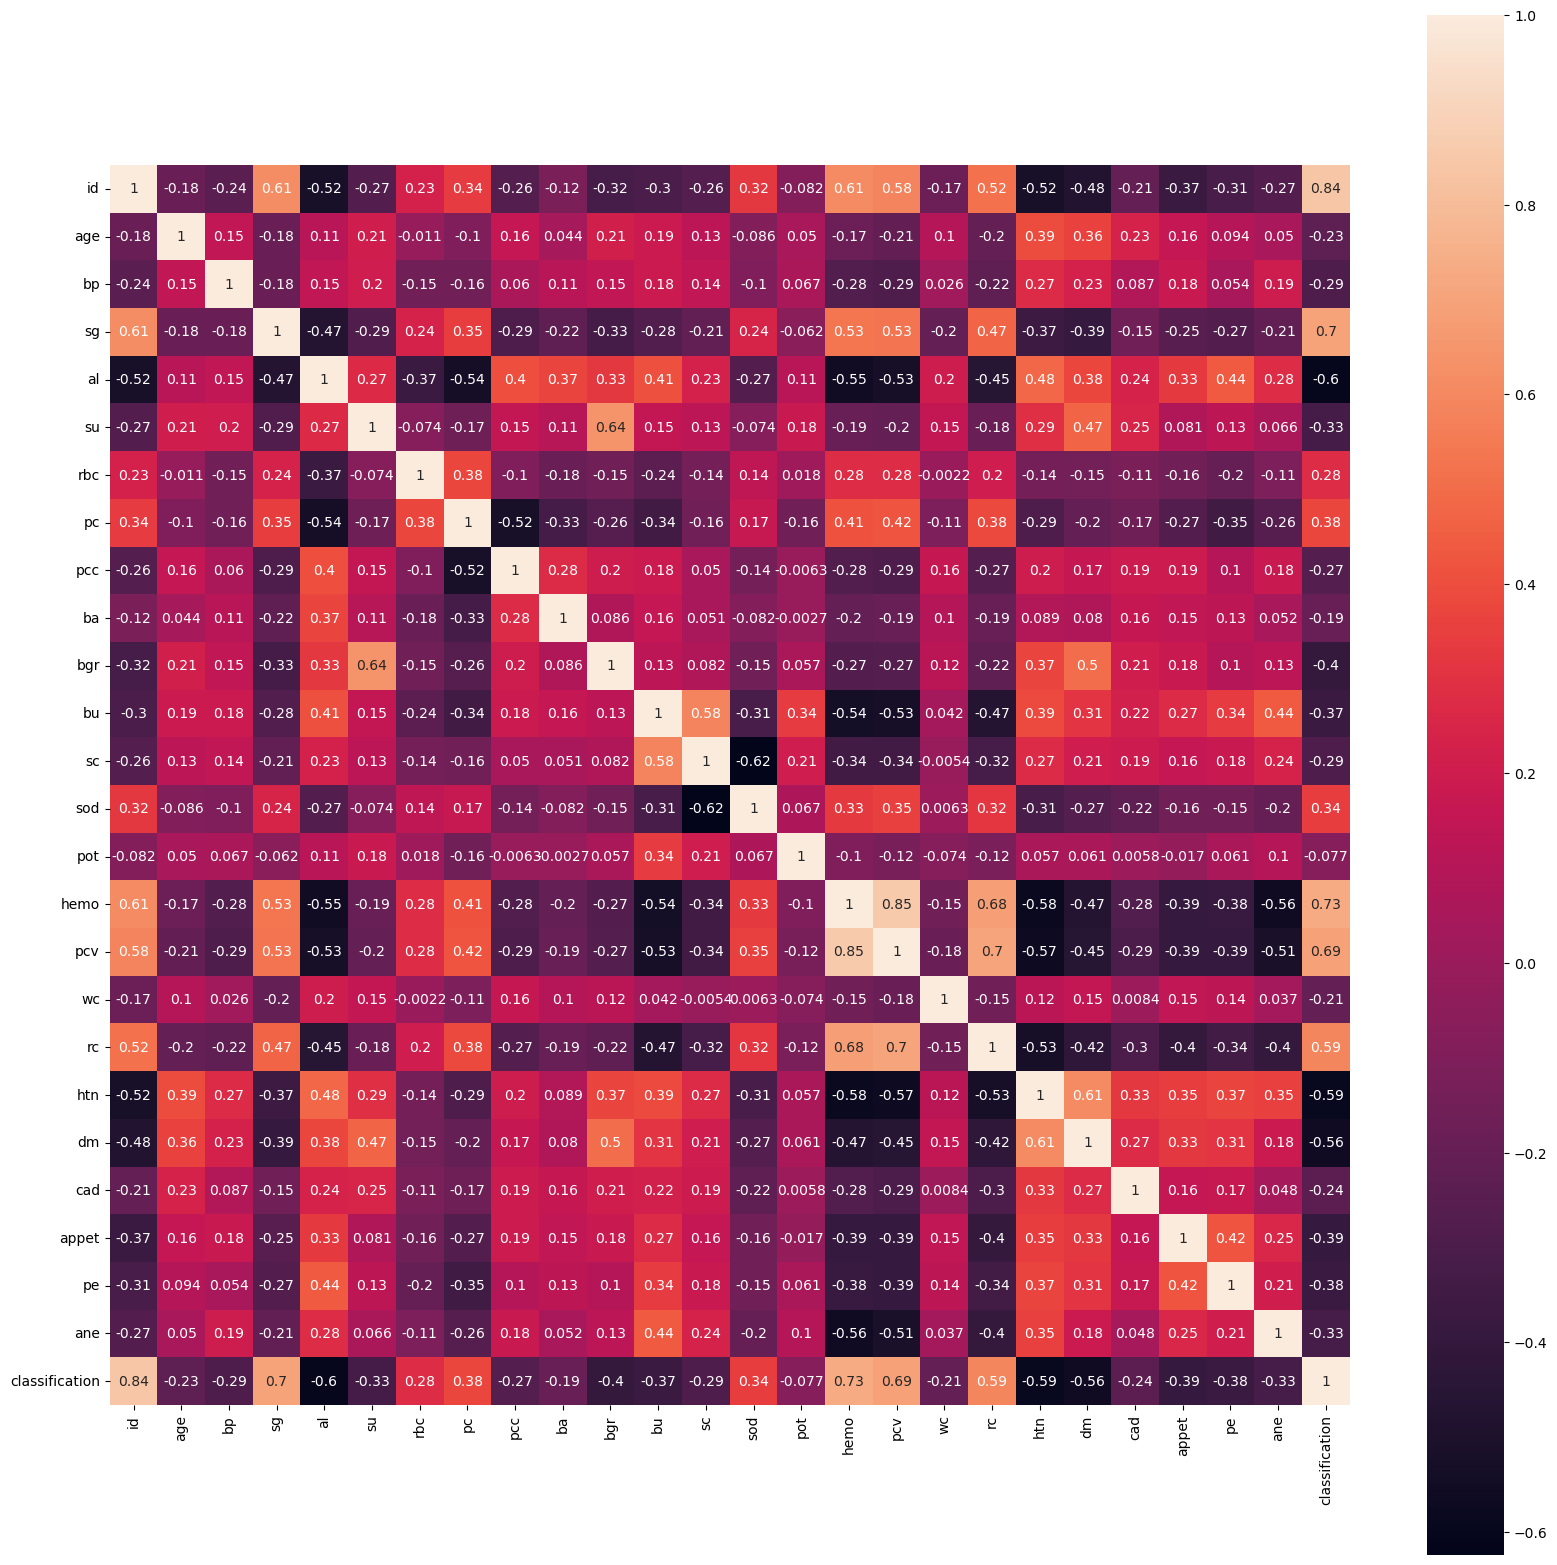

In [121]:
# Heatmap of the correlation of features to the target variable

corr = df.corr()

plt.figure(figsize = (20,20))
sns.heatmap(corr, annot = True, square = True)

* From the visual above, we can see that the features with the highest correlation to the target variable (classification) are 'al', 'sg', 'hemo', and 'pcv'

In [122]:
x = df[['al', 'sg', 'hemo', 'pcv']]
y = df[['classification']]

In [123]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 20)

In [130]:
model = {'RFC': RandomForestClassifier(), 
         'LR': LogisticRegression(), 
         'DTC': DecisionTreeClassifier()}

for model_name, model in model.items():
    model.fit(x_train, y_train)

    prediction = model.predict(x_test)

    accuracy = accuracy_score(y_test, prediction)
    print(f'{model_name} Accuracy:{accuracy:2f}')

    report = classification_report(y_test, prediction)
    print(report)
    print('************************************************************')

RFC Accuracy:0.987500
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        46
           1       0.97      1.00      0.99        34

    accuracy                           0.99        80
   macro avg       0.99      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80

************************************************************
LR Accuracy:0.975000
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        46
           1       0.94      1.00      0.97        34

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80

************************************************************
DTC Accuracy:0.937500
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        46
           1       0.89      0.97      0.93       